In [1]:
import tensorflow as tf
print(tf.__version__)

2.11.0


# MNIST Hand Writing digits

listing 2.1 loading the MNIST dataset in Keras


In [2]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [3]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [4]:
train_images[0].ndim

2

In [5]:
train_images[0].shape

(28, 28)

In [6]:
train_images.shape

(60000, 28, 28)

In [7]:
test_images.shape

(10000, 28, 28)

In [8]:
train_labels[0]

5

In [9]:
test_labels[0]

7

In [10]:
from tensorflow.keras import models
from tensorflow.keras import layers
network = models.Sequential()
network.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
network.add(layers.Dense(10, activation='softmax'))


# Listing 2.3 The compilation step


In [11]:
network.compile(optimizer='rmsprop', 
                loss='categorical_crossentropy', 
                metrics=['accuracy'])

# Listing 2.4 Preparing the image data

In [12]:
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

# listing 2.5 Preparing the labels (One hot encoding)

In [13]:
from tensorflow.keras.utils import to_categorical
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)


In [14]:
network.fit(train_images, train_labels, epochs=10, batch_size=150)

Epoch 1/10
400/400 [==============================] - 4s 8ms/step - loss: 0.2737 - accuracy: 0.9218
Epoch 2/10
400/400 [==============================] - 3s 8ms/step - loss: 0.1122 - accuracy: 0.9673
Epoch 3/10
400/400 [==============================] - 3s 8ms/step - loss: 0.0751 - accuracy: 0.9781
Epoch 4/10
400/400 [==============================] - 3s 8ms/step - loss: 0.0539 - accuracy: 0.9839
Epoch 5/10
400/400 [==============================] - 3s 8ms/step - loss: 0.0412 - accuracy: 0.9876
Epoch 6/10
400/400 [==============================] - 3s 8ms/step - loss: 0.0320 - accuracy: 0.9906
Epoch 7/10
400/400 [==============================] - 3s 8ms/step - loss: 0.0238 - accuracy: 0.9932
Epoch 8/10
400/400 [==============================] - 3s 8ms/step - loss: 0.0179 - accuracy: 0.9950
Epoch 9/10
400/400 [==============================] - 3s 8ms/step - loss: 0.0146 - accuracy: 0.9960
Epoch 10/10
400/400 [==============================] - 3s 8ms/step - loss: 0.0105 - accuracy: 0.9976

In [15]:
test_loss, test_acc = network.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

313/313 [==============================] - 1s 3ms/step - loss: 0.0640 - accuracy: 0.9813
Test accuracy: 0.9812999963760376


In [16]:
network.predict(test_images)

313/313 [==============================] - 1s 3ms/step


array([[6.07536133e-10, 1.69888839e-10, 1.40427247e-07, ...,
        9.99995768e-01, 4.05848244e-09, 1.01806336e-07],
       [1.40335032e-09, 1.42411423e-07, 9.99999821e-01, ...,
        9.64283906e-16, 4.48103741e-08, 9.59333899e-17],
       [1.89714669e-07, 9.99699116e-01, 7.43389464e-05, ...,
        5.00032365e-05, 1.71636580e-04, 3.80545480e-08],
       ...,
       [3.12584618e-16, 5.69272751e-14, 2.55211874e-15, ...,
        3.20274047e-08, 4.22027613e-09, 5.29564623e-08],
       [3.79288245e-09, 1.04206426e-11, 6.95280118e-12, ...,
        2.89847923e-09, 2.19133290e-05, 5.34947303e-13],
       [7.25744265e-09, 4.78160729e-15, 4.24757479e-10, ...,
        2.02763448e-16, 2.46628000e-12, 4.50902727e-12]], dtype=float32)

In [17]:
network.predict(test_images)[0]

313/313 [==============================] - 1s 3ms/step


array([6.07536133e-10, 1.69888839e-10, 1.40427247e-07, 3.90874675e-06,
       1.28763806e-14, 1.23056787e-10, 7.30285634e-15, 9.99995768e-01,
       4.05848244e-09, 1.01806336e-07], dtype=float32)

In [18]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(train_images.ndim)
print(train_images.shape)
print(train_images.dtype)


3
(60000, 28, 28)
uint8


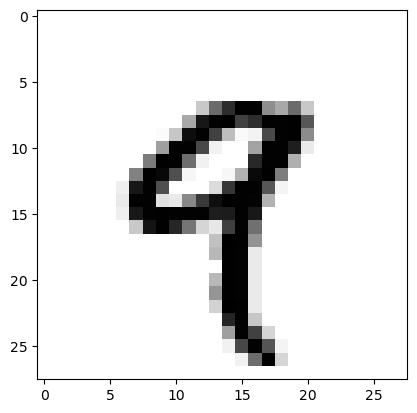

In [19]:
digit = train_images[4]
import matplotlib.pyplot as plt
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

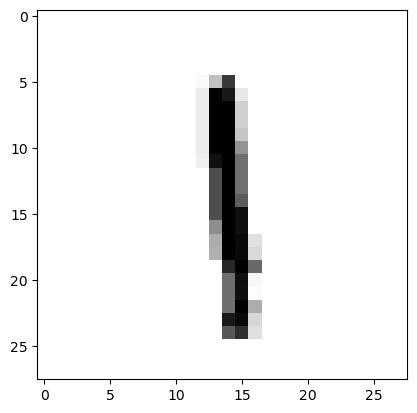

In [20]:
digit = train_images[8]
import matplotlib.pyplot as plt
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

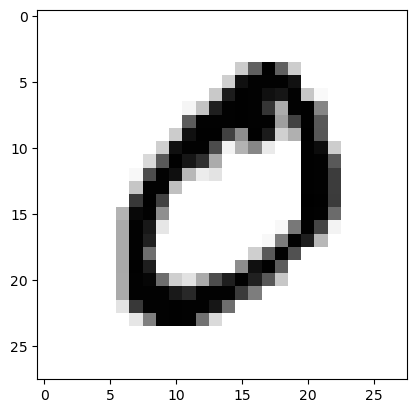

In [21]:
digit = train_images[1]
import matplotlib.pyplot as plt
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()